# IMDb Movie Review Sentiment Analysis: Exploratory Data Analysis (EDA)

This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the IMDb Large Movie Review Dataset. The goal is to understand the characteristics of the movie review text, analyze sentiment distribution, identify key features, and inform the preprocessing and model selection stages for a sentiment analysis application.

**Dataset Source:** [IMDb Large Movie Review Dataset on Kaggle](https://www.kaggle.com/datasets/pranayprasad/aclimdb)

# Setup and Installations

In [1]:
#Activating toch for CPU usage

import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("⚠️ GPU unavailaible! Check installation")

%config InlineBackend.figure_format = 'retina'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PyTorch version: 2.7.1+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Ti
CUDA version: 12.8


In [2]:
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
import tarfile
import os
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import joblib

from collections import Counter
from bs4 import BeautifulSoup
from wordcloud import WordCloud
from os import path
from PIL import Image
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from torch.utils.data import Dataset, DataLoader


# Data Loading

## Data Loading and Initial Inspection

First, we load the dataset and perform an initial inspection to understand its structure, data types, and check for any missing values. This step is crucial for ensuring data quality before proceeding with analysis.

In [66]:
from pathlib import Path

try:
    from pathlib import Path
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    PROJECT_ROOT = Path.cwd()
    while not (PROJECT_ROOT / 'data').exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

print(PROJECT_ROOT)

d:\Code\projects\SentimentAnalysis


In [ ]:
import tarfile

file_path = PROJECT_ROOT / 'data' / 'aclImdb_v1.tar.gz'
destination_path = PROJECT_ROOT / 'data' / 'extractedData'

try:
    with tarfile.open(file_path, 'r:gz') as tar:
        tar.extractall(path=destination_path)
    print('File extracted successfully!')
except FileNotFoundError:
    print(f'Error: File not found at {file_path}')
except Exception as e:
    print(f'An error occurred: {e}')


C:\Users\User\AppData\Local\Temp\ipykernel_23340\3752888732.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=destination_path)


File extracted successfully!


In [ ]:
def extract_file(file_path):
    try:
        filename = os.path.basename(file_path)
        name_part = filename.split('.')[0].split('_')
        with open(file_path, 'r', encoding='utf-8') as file:
            content = file.readlines()
            name_part += content
        return name_part
    except (FileNotFoundError, IOError, UnicodeDecodeError) as e:
        print(f'Error processing {filename}: {e}')
        return None

folder_path = [PROJECT_ROOT / 'data' / 'extractedData' / 'aclImdb' / 'train' / 'neg', PROJECT_ROOT / 'data' / 'extractedData' / 'aclImdb' / 'train' / 'pos']

df_list = []
for folder in folder_path:
    file_list = os.listdir(folder)
    for file in file_list:
        if file.endswith('.txt'):
            file_path = os.path.join(folder, file)
            result = extract_file(file_path)
            if result is not None:
                df_list.append(result)

In [7]:
df = pd.DataFrame(df_list, columns=['id', 'rating','review'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      25000 non-null  object
 1   rating  25000 non-null  object
 2   review  25000 non-null  object
dtypes: object(3)
memory usage: 586.1+ KB


In [8]:
df.head()

,id,rating,review
0,0,3,Story of a man who has unnatural feelings for ...
1,10000,4,Airport '77 starts as a brand new luxury 747 p...
2,10001,4,This film lacked something I couldn't put my f...
3,10002,1,"Sorry everyone,,, I know this is supposed to b..."
4,10003,1,When I was little my parents took me along to ...


### Initial Observations

The dataset consists of 25000 entries, with 3 columns: `review` (text), `id`, and `rating` (target label). There are no missing values, indicating a clean dataset ready for further exploration.

## Data Preprocessing

Raw text data is noisy and unsuitable for direct model input. This section outlines the preprocessing steps applied to clean and transform the review text, ensuring consistency and improving feature quality.

In [4]:
def cleanText(text):
    #remove html tags
    text = BeautifulSoup(text, 'html.parser').get_text()

    #remove punctuation
    text = re.sub(r"[^\w\s']|_", ' ', text)
    
    #remove whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    #convert to lowercase
    text = text.lower()

    #tokenize
    tokens = word_tokenize(text)

    #remove stopwords
    tokens = [word for word in tokens if word not in stopwords.words('english')]

    #lemmatize
    lemmatizer = WordNetLemmatizer()
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(lemmatized)


In [ ]:
# df['processed_review'] = df['review'].apply(cleanText)

In [ ]:
import swifter

df['processed_review'] = df['review'].swifter.apply(cleanText)

In [9]:
df['rating'] = df['rating'].astype(int)
df['classes'] = df['rating'].apply(lambda x: 1 if x > 5 else 0)

In [10]:
df.head()

,id,rating,review,processed_review,classes
0,0,3,Story of a man who has unnatural feelings for ...,story man unnatural feeling pig start opening ...,0
1,10000,4,Airport '77 starts as a brand new luxury 747 p...,airport '77 start brand new luxury 747 plane l...,0
2,10001,4,This film lacked something I couldn't put my f...,film lacked something could n't put finger fir...,0
3,10002,1,"Sorry everyone,,, I know this is supposed to b...",sorry everyone know supposed art film wow hand...,0
4,10003,1,When I was little my parents took me along to ...,little parent took along theater see interior ...,0


In [ ]:
folder_name = PROJECT_ROOT / 'data' / 'SA_EDA'
file_path = os.path.join(folder_name, 'processed_reviews.parquet')


In [ ]:
#Save dataframe for future use

df.to_parquet(file_path)

print(f'DataFrame successfully saved to {file_path}')

DataFrame successfully saved to D:\Code\projects\SentimentAnalysis\data\SA_EDA\processed_reviews.parquet


In [68]:
#load dataframe to save time

def cleanText(text):
    #remove html tags
    text = BeautifulSoup(text, 'html.parser').get_text()

    #remove punctuation
    text = re.sub(r"[^\w\s']|_", ' ', text)
    
    #remove whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    #convert to lowercase
    text = text.lower()

    #tokenize
    tokens = word_tokenize(text)

    #remove stopwords
    tokens = [word for word in tokens if word not in stopwords.words('english')]

    #lemmatize
    lemmatizer = WordNetLemmatizer()
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(lemmatized)


folder_name = PROJECT_ROOT / 'data' / 'SA_EDA'
file_path = os.path.join(folder_name, 'processed_reviews.parquet')


try:
    df_processed = pd.read_parquet(file_path)
    print(f'DataFrame successfully loaded from parquet file. {file_path}')

    print('\nDataFrame info:')
    df_processed.info()

except:
    print(f'Error loading DataFrame from parquet file. {file_path}')

DataFrame successfully loaded from parquet file. d:\Code\projects\SentimentAnalysis\data\SA_EDA\processed_reviews.parquet

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                25000 non-null  object
 1   rating            25000 non-null  int64 
 2   review            25000 non-null  object
 3   processed_review  25000 non-null  object
 4   classes           25000 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 976.7+ KB


### Conclusion: Cleaned and Standardized Text

The preprocessing pipeline successfully transformed raw, unstructured review text into a cleaned and standardized format. Steps like lowercasing, HTML/punctuation removal, and tokenization prepare the data for effective feature extraction and model training.

# Exploratory Data Analysis

## Data Overview

## Sentiment Distribution

Understanding the distribution of sentiment labels is vital to identify class imbalance, which can impact model training. We'll visualize the counts of positive and negative reviews.


In [8]:
df = df_processed

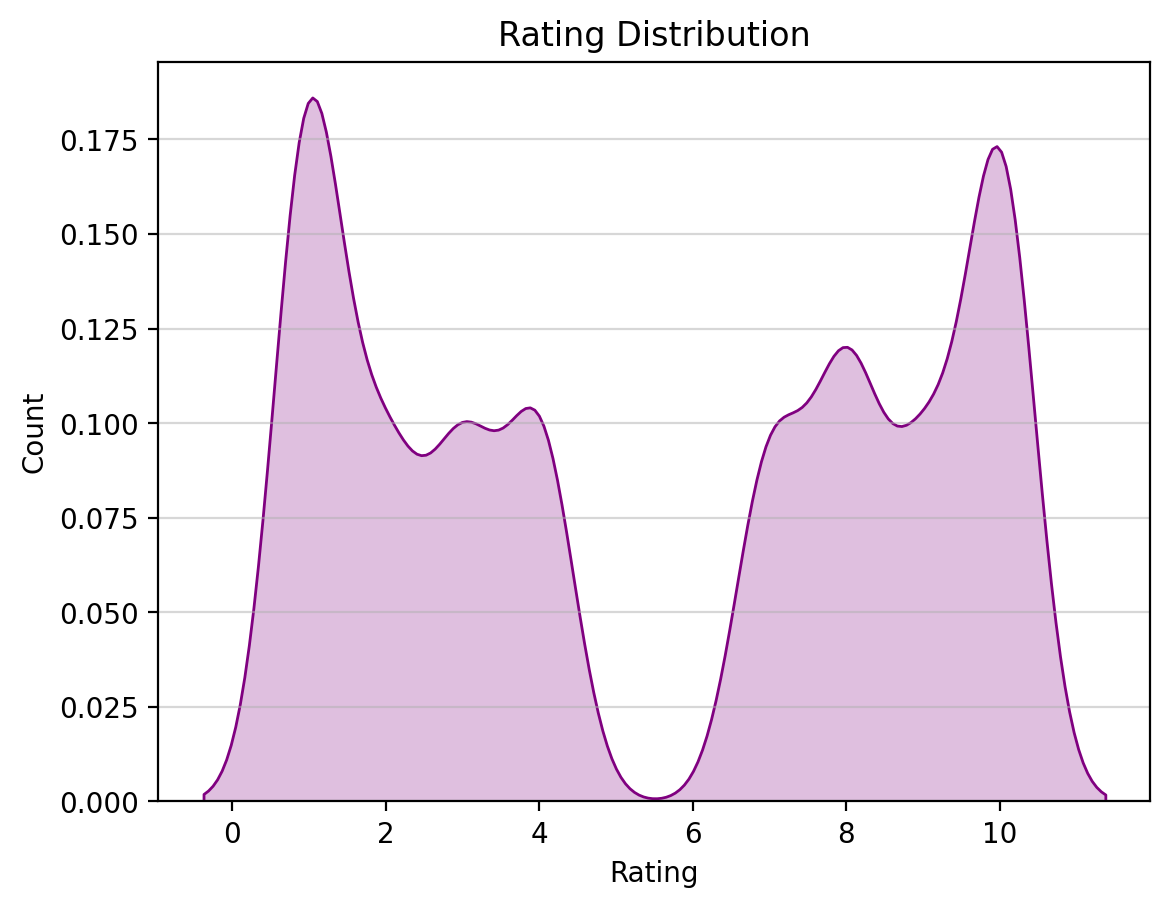

In [9]:
sns.kdeplot(data=df, x='rating', color='purple', fill=True, bw_adjust=1)

plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.5)
plt.xticks(rotation=0)

plt.show()

### Conclusion: Balanced Classes

The sentiment distribution shows a relatively balanced dataset, with an approximately equal number of positive and negative reviews. This is beneficial for training, as it reduces the risk of models being biased towards a majority class.

## Review Length Analysis

Analyzing the length of reviews (in words or characters) provides insights into text variability. This helps in determining appropriate sequence lengths for deep learning models (e.g., padding/truncation lengths) and understanding potential feature complexity.

C:\Users\User\AppData\Local\Temp\ipykernel_19768\4262430749.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classes', y='p_review_words_amount', data=avg_words_by_classes,


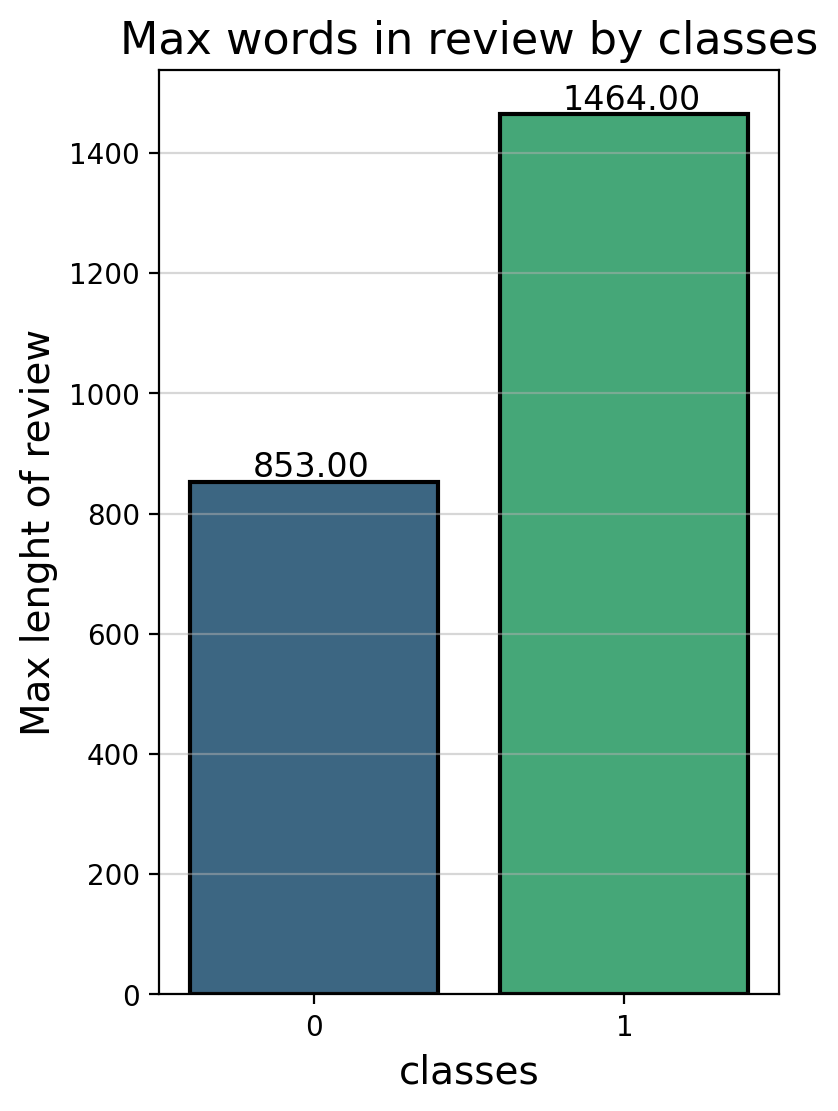

In [55]:
df['p_review_words_amount'] = df['processed_review'].apply(lambda x: len(x.split()))
avg_words_by_classes = df.groupby('classes')['p_review_words_amount'].max().reset_index()


plt.figure(figsize=(4, 6))
sns.barplot(x='classes', y='p_review_words_amount', data=avg_words_by_classes,
            palette='viridis', edgecolor='k', linewidth=1.5)

plt.title('Max words in review by classes', fontsize=16)
plt.xlabel('classes', fontsize=14)
plt.ylabel('Max lenght of review', fontsize=14)
plt.grid(axis='y', alpha=0.5)
plt.xticks(rotation=0)

for i, row in avg_words_by_classes.iterrows():
    plt.text(i-0.2, row['p_review_words_amount']+8,
             f'{row['p_review_words_amount']:.2f}',
             color='black', fontsize=12)

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_19768\264690852.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classes', y='p_review_length', data=avg_p_length_by_classes,


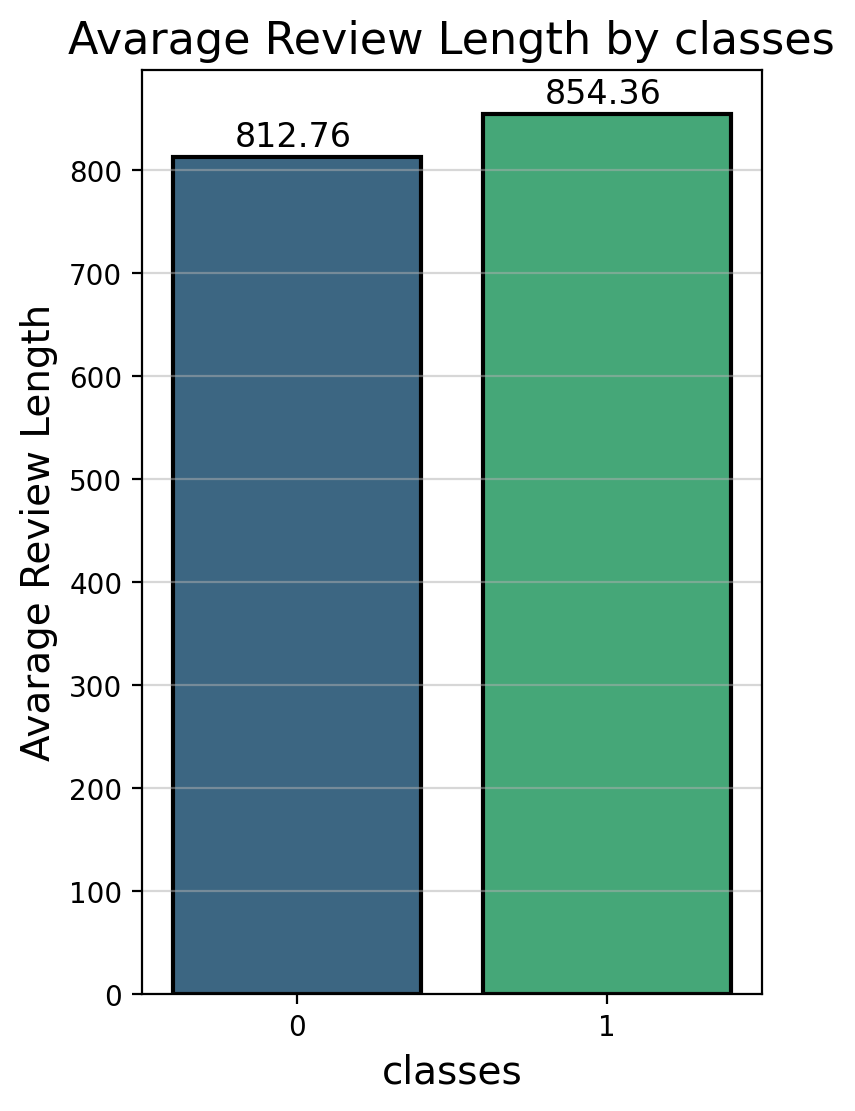

In [57]:
df['p_review_length'] = df['processed_review'].str.len()
avg_p_length_by_classes = df.groupby('classes')['p_review_length'].mean().reset_index()

plt.figure(figsize=(4, 6))
sns.barplot(x='classes', y='p_review_length', data=avg_p_length_by_classes,
            palette='viridis', edgecolor='k', linewidth=1.5)

plt.title('Avarage Review Length by classes', fontsize=16)
plt.xlabel('classes', fontsize=14)
plt.ylabel('Avarage Review Length', fontsize=14)
plt.grid(axis='y', alpha=0.5)
plt.xticks(rotation=0)

for i, row in avg_p_length_by_classes.iterrows():
    plt.text(i-0.2, row['p_review_length']+10,
             f'{row['p_review_length']:.2f}',
             color='black', fontsize=12)

plt.show()

In [44]:
stats = {}
for rating in range(1, 11):
    reviews = df[df['rating'] == rating]['processed_review']
    word_lengths = reviews.apply(lambda x: len(x.split()))
    char_lengths = reviews.apply(len)
    
    stats[rating] = {
        'min_words': word_lengths.min(),
        'max_words': word_lengths.max(),
        'avg_words': word_lengths.mean(),
        'avg_chars': char_lengths.mean()
    }

stats_df = pd.DataFrame.from_dict(stats, orient='index')
stats_df


,min_words,max_words,avg_words,avg_chars
1,6.0,769.0,112.584118,730.359608
2,9.0,614.0,121.767951,796.330560
3,4.0,668.0,135.322314,889.706198
4,13.0,853.0,138.066395,913.475519
5,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN
7,15.0,627.0,142.852564,950.747997
8,13.0,604.0,138.028581,923.695912
9,7.0,1464.0,133.544410,892.238179
10,9.0,922.0,112.193153,741.323119


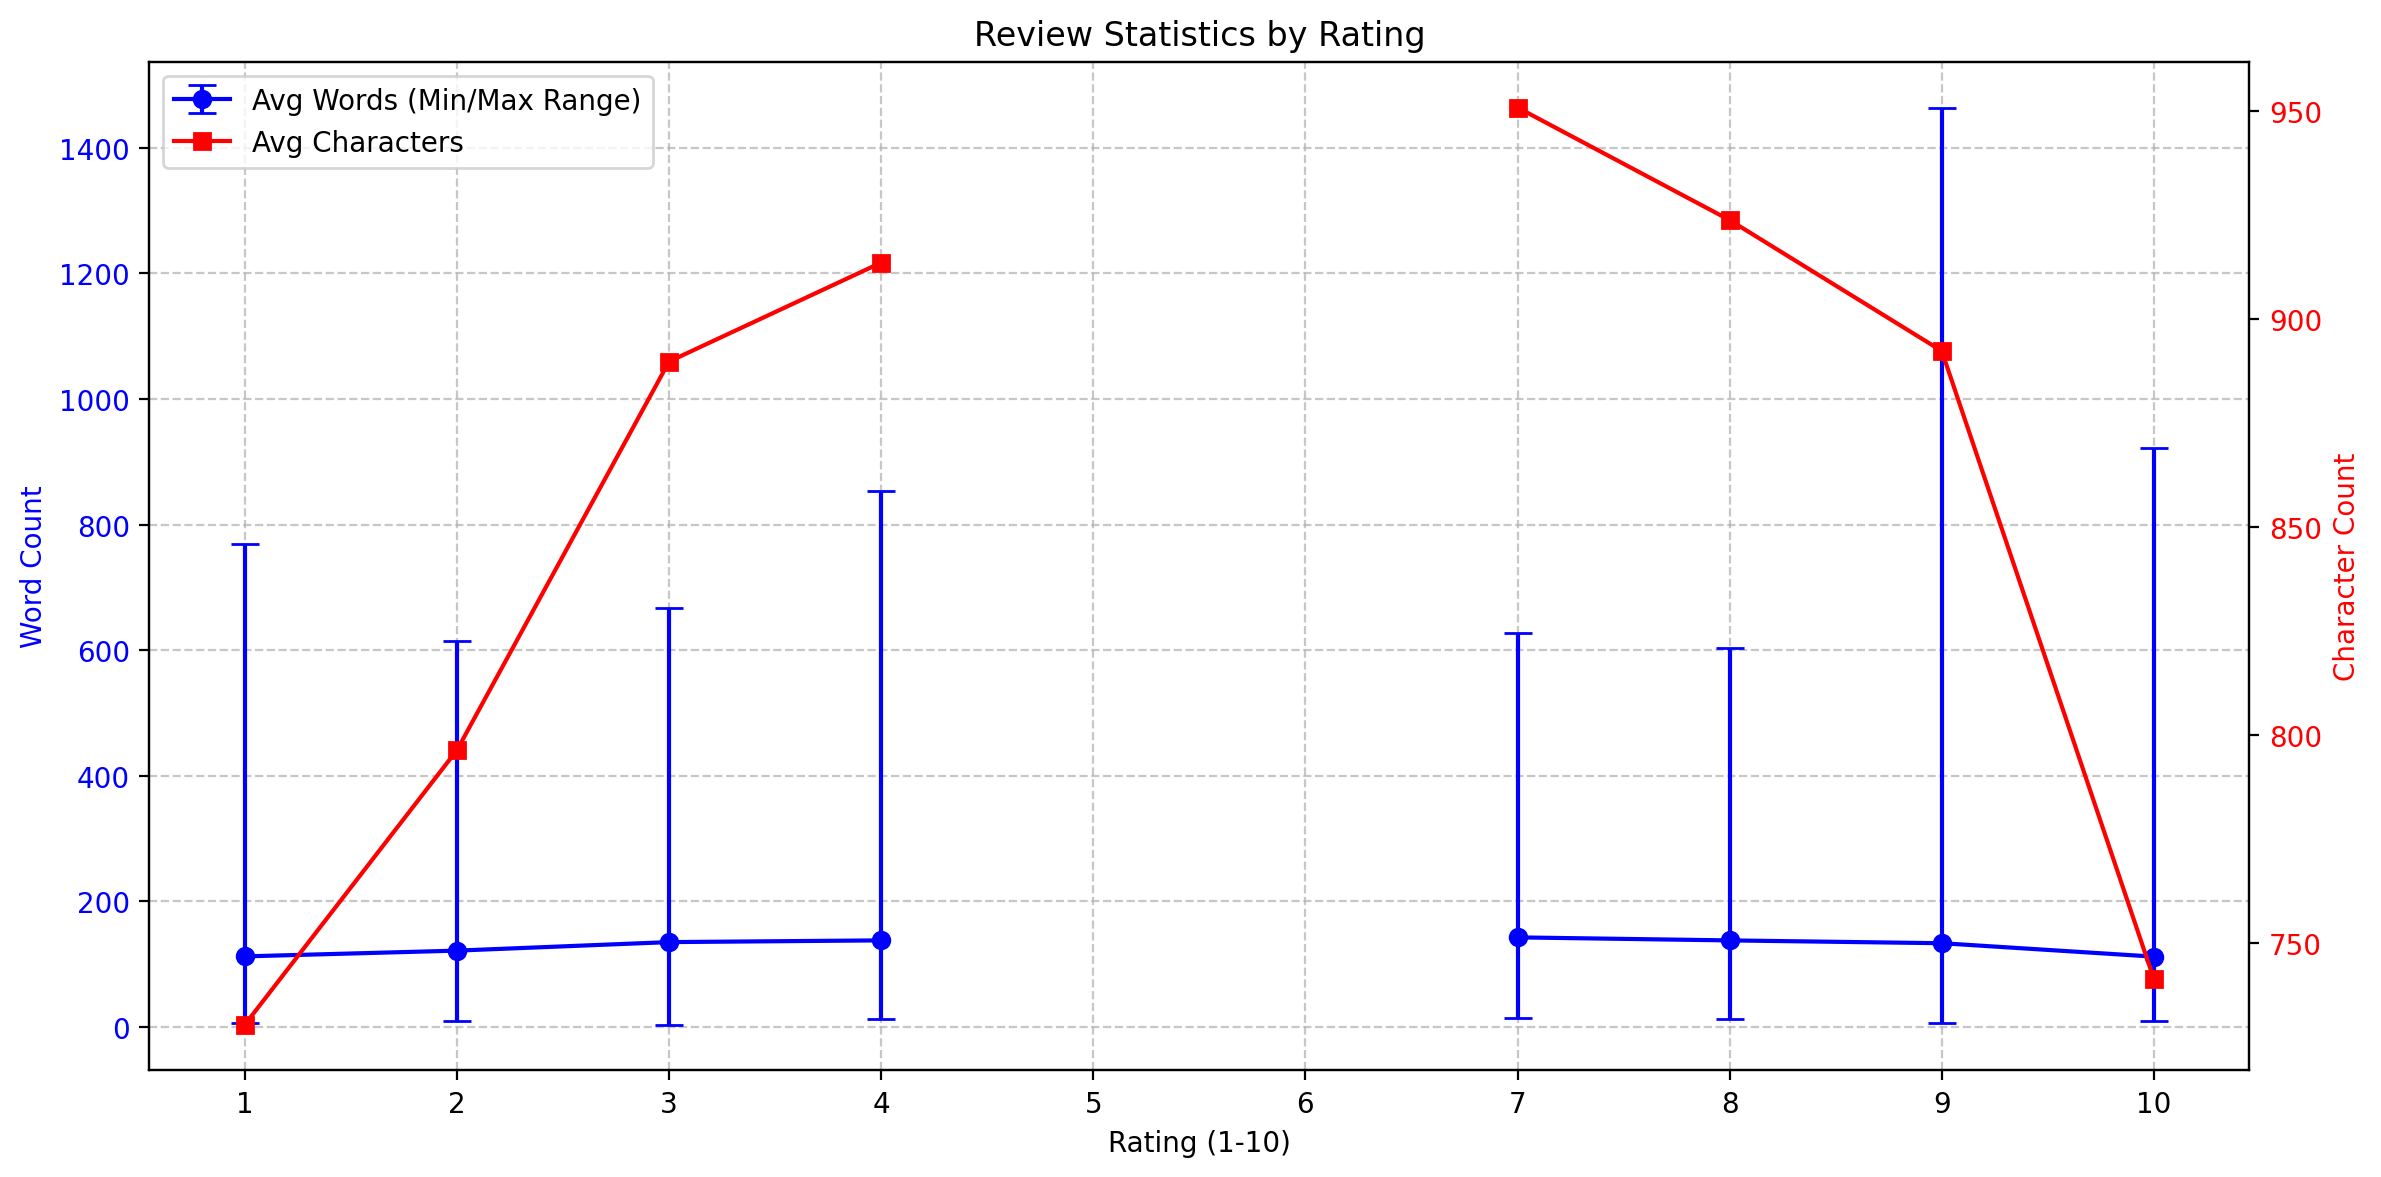

In [46]:
ratings = np.arange(1, 11)
avg_words = stats_df['avg_words'].values # Average words
min_words = stats_df['min_words'].values # Min words
max_words = stats_df['max_words'].values # Max words
avg_chars = stats_df['avg_chars'].values # Avg characters


# Calculate error bars (distance from avg to min/max)
lower_error = [avg - min for avg, min in zip(avg_words, min_words)]
upper_error = [max - avg for max, avg in zip(max_words, avg_words)]
errors = [lower_error, upper_error]

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot avg words with error bars (primary axis)
ax1.errorbar(ratings, avg_words, yerr=errors, 
             fmt='o-', color='blue', capsize=5, 
             label='Avg Words (Min/Max Range)')
ax1.set_xlabel('Rating (1-10)')
ax1.set_ylabel('Word Count', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(ratings)
ax1.grid(True, linestyle='--', alpha=0.7)

# Create secondary axis for characters
ax2 = ax1.twinx()
ax2.plot(ratings, avg_chars, 's-r', label='Avg Characters')
ax2.set_ylabel('Character Count', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add legends and title
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.title('Review Statistics by Rating')
plt.tight_layout()
plt.show()

### Conclusion: Varied Lengths, Long Tail

Most reviews fall within 150 to 170 words. This highlights the need for effective padding/truncation strategies for neural networks.


## Word Frequency and Word Clouds

To identify the most common words and themes in movie reviews, we'll examine word frequencies and visualize them using word clouds. This helps us understand the dominant vocabulary, both overall and specific to positive/negative sentiments.

In [ ]:
#Create a wordcloud of the reviews

neutral = 5

positive = df['rating'] > neutral + 3
negative = df['rating'] < neutral - 3

positive_reviews = df[positive]['processed_review']
negative_reviews = df[negative]['processed_review']

text = ' '.join(df['processed_review'].astype(str))
positive_text = ' '.join(positive_reviews.astype(str))
negative_text = ' '.join(negative_reviews.astype(str))

camera_mask_path = PROJECT_ROOT / 'data' / 'imdb logo' / 'camera.webp'
camera_mask = np.array(Image.open(camera_mask_path))

cloud_mask_path = PROJECT_ROOT / 'data' / 'imdb logo' / 'cloud.png'
cloud_mask = np.array(Image.open(cloud_mask_path))


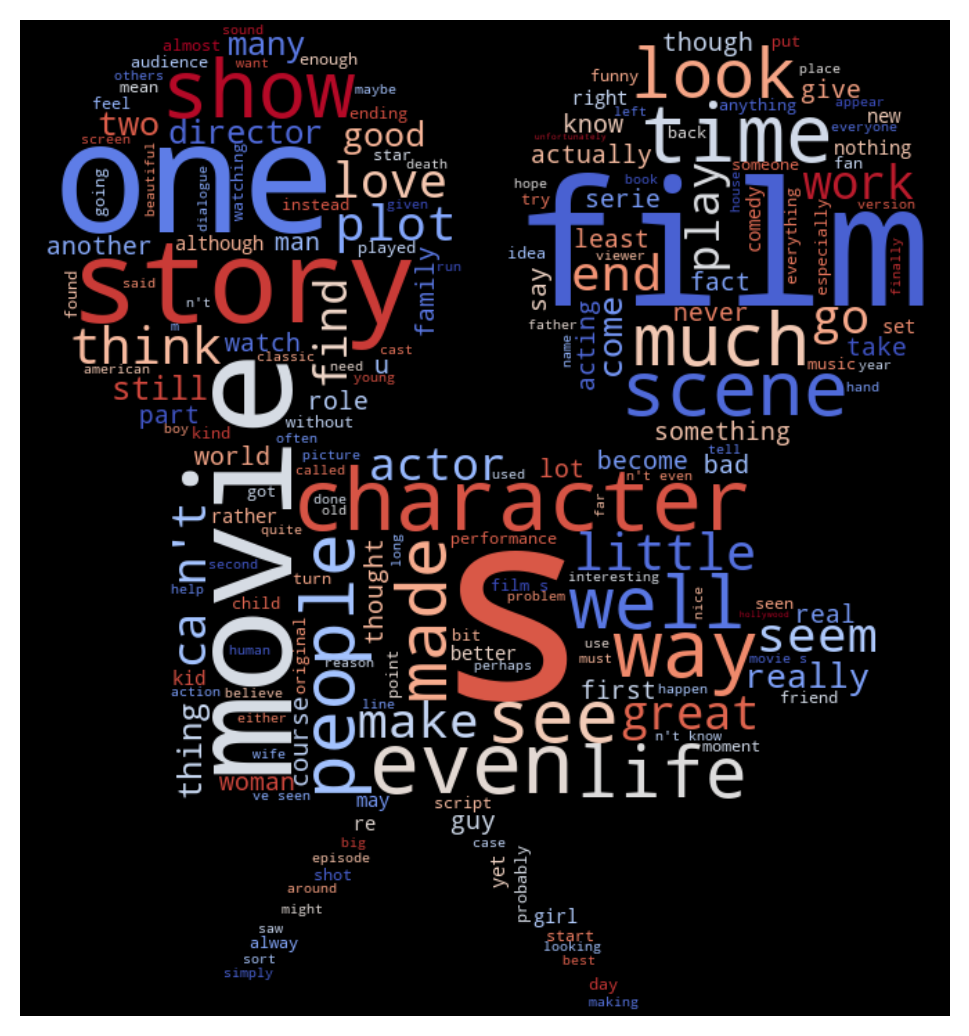

In [70]:
wordcloud = WordCloud(
    mask=camera_mask,
    background_color='black',
    colormap='coolwarm',
    stopwords=None
).generate(text)

fig, ax = plt.subplots(1, 1, figsize=(6, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

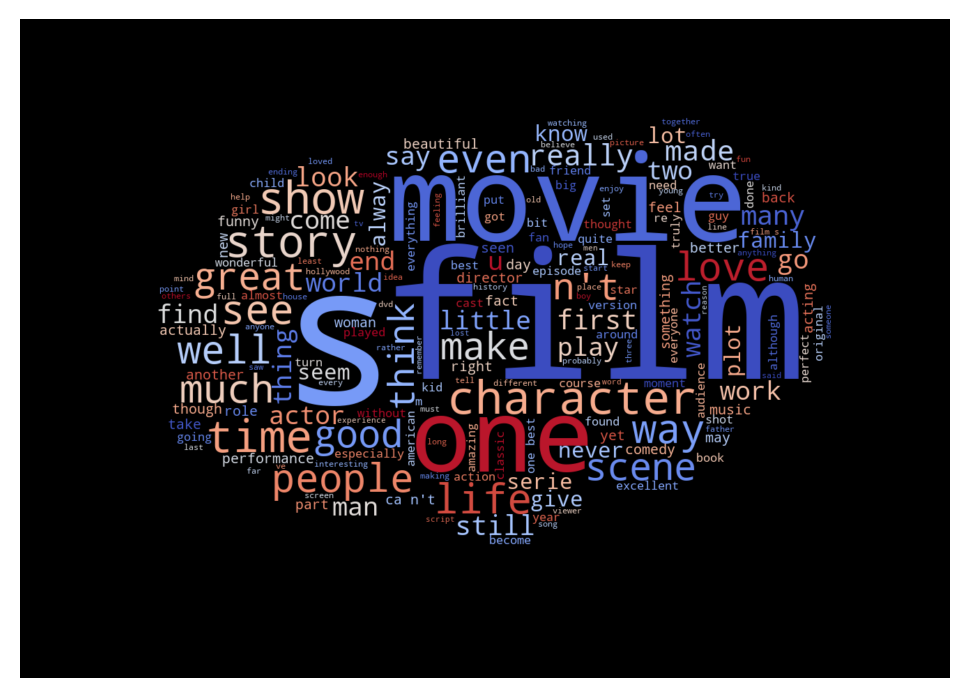

In [77]:
wordcloud = WordCloud(
    mask=cloud_mask,
    background_color='black',
    colormap='coolwarm',
    stopwords=None
).generate(positive_text)

fig, ax = plt.subplots(1, 1, figsize=(6, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


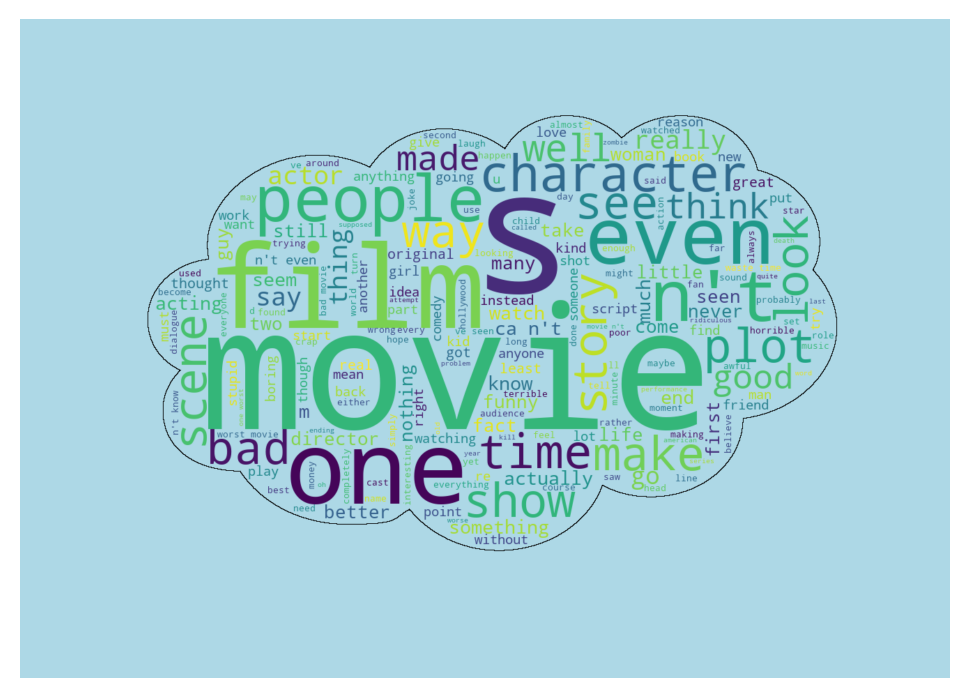

In [83]:
wordcloud = WordCloud(
    mask=cloud_mask,
    background_color='lightblue',
    colormap='viridis',
    stopwords=None,
    contour_width=1,
    contour_color='black'
).generate(negative_text)

fig, ax = plt.subplots(1, 1, figsize=(6, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## Summary of Exploratory Data Analysis Findings

This EDA provided crucial insights into the IMDb movie review dataset:

* **Balanced Sentiment Distribution:** The positive and negative classes are well-balanced, which is ideal for training robust classification models without significant bias towards one class.
* **Varied Review Lengths:** Reviews exhibit a wide range of lengths, necessitating strategies like padding or truncation for consistent input into deep learning models.
* **Discriminative Vocabulary:** Not distinctive positive and negative keywords were identified, confirming the presence of low lexical indicators for sentiment.
* **Clean Dataset:** The dataset was found to be free of missing values, simplifying the initial data preparation phase.

These findings will directly inform the subsequent stages of model development, including feature engineering (e.g., TF-IDF for Logistic Regression, GloVe embeddings for CNN) and the selection of appropriate model architectures and hyperparameters.

# Model Training 

## Logistic regression kfold

In [ ]:
x = df['processed_review']
y = df['classes']

pos_label_encoded = 1

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

vectorizer = TfidfVectorizer(max_features=4000, ngram_range=(1, 3))
lr_model = LogisticRegression(C=1, solver='lbfgs', max_iter=1000, random_state=15)

print('Starting cross-validation...')
for fold, (train_index, test_index) in enumerate(skf.split(x, y)):
    print(f'\n--- Fold {fold + 1}/{skf.n_splits} ----')

    X_train, X_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    x_train_tfidf = vectorizer.fit_transform(X_train)
    x_test_tfidf = vectorizer.transform(X_test)

    lr_model.fit(x_train_tfidf, y_train)

    y_pred = lr_model.predict(x_test_tfidf)

    accuracy_scores.append(accuracy_score(y_test, y_pred))
    precision_scores.append(precision_score(y_test, y_pred, pos_label=pos_label_encoded, zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred, pos_label=pos_label_encoded, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred, pos_label=pos_label_encoded, zero_division=0))

print('\n--- Final Cross-Validation Results ---')
print(f'Average Accuracy: {np.mean(accuracy_scores):.4f}')
print(f'Average Precision: {np.mean(precision_scores):.4f}')
print(f'Average Recall: {np.mean(recall_scores):.4f}')
print(f'Average F1-Score: {np.mean(f1_scores):.4f}')

Starting cross-validation...

--- Fold 1/5 ----

--- Fold 2/5 ----

--- Fold 3/5 ----

--- Fold 4/5 ----

--- Fold 5/5 ----

--- Final Cross-Validation Results ---
Average Accuracy: 0.8805
Average Precision: 0.8713
Average Recall: 0.8930
Average F1-Score: 0.8820


## Logistic Regression

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    df['processed_review'], df['classes'], test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=4000, ngram_range=(1, 3))

x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

lr_model = LogisticRegression(C=1, solver='lbfgs', max_iter=1000, random_state=15)
lr_model.fit(x_train_tfidf, y_train)

y_pred = lr_model.predict(x_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')


Accuracy: 0.88


In [14]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      2515
           1       0.87      0.89      0.88      2485

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



In [ ]:
vectorizer_save_path = PROJECT_ROOT / 'sentiment_app' / 'models' / 'tfidf_vectorizer.joblib'
joblib.dump(vectorizer, vectorizer_save_path)
print(f'Vectorizer saved to: {vectorizer_save_path}')

Vectorizer saved to: D:\Code\projects\SentimentAnalysis\sentiment_app\models\tfidf_vectorizer.joblib


In [ ]:
lr_model_path = PROJECT_ROOT / 'sentiment_app' / 'models' / 'lr_model.joblib'
joblib.dump(lr_model, lr_model_path)
print(f'LR model saved to: {lr_model_path}')


['D:\\Code\\projects\\SentimentAnalysis\\sentiment_app\\models\\lr_model.joblib']

## CNN model

### Text formating

In [45]:
def count_words(clean_text):
    word_list = []
    for text in clean_text:
        word_list.extend(text.split())
    
    word_count = Counter(word_list)

    return word_count

word_counts_dict = count_words(df['processed_review'])

print(word_counts_dict.most_common(10))


[("'s", 62326), ('movie', 51666), ('film', 47017), ("n't", 33473), ('one', 27725), ('like', 20736), ('time', 15948), ('good', 15174), ('character', 14169), ('would', 13486)]


In [46]:
PAD_TOKEN = '<pad>'
UNK_TOKEN = '<unk>'

def create_vocabulary(word_counts, vocab_size=15000):
    idx = 0
    word_to_idx = {PAD_TOKEN: idx}
    idx_to_word = {idx: PAD_TOKEN}

    idx += 1
    word_to_idx[UNK_TOKEN] = idx
    idx_to_word[idx] = UNK_TOKEN

    common_words = word_counts.most_common(vocab_size - 2)
    for word, _ in common_words:
        idx += 1
        word_to_idx[word] = idx
        idx_to_word[idx] = word

    return word_to_idx, idx_to_word

word_to_idx, idx_to_word = create_vocabulary(word_counts_dict)

print('Vocabulary size:', len(word_to_idx))
print('Vocabulary example:', list(word_to_idx.items())[:10])

Vocabulary size: 15000
Vocabulary example: [('<pad>', 0), ('<unk>', 1), ("'s", 2), ('movie', 3), ('film', 4), ("n't", 5), ('one', 6), ('like', 7), ('time', 8), ('good', 9)]


In [ ]:
cnn_tokenizer_path = PROJECT_ROOT / 'sentiment_app' / 'models' / 'cnn_tokenizer.joblib'
joblib.dump(word_to_idx, cnn_tokenizer_path)
print(f'CNN tokenizer saved to: {cnn_tokenizer_path}')


['D:\\Code\\projects\\SentimentAnalysis\\sentiment_app\\models\\cnn_tokenizer.joblib']

In [48]:
def text_to_sequence(clean_text, word_to_idx):
    unk_idx = word_to_idx[UNK_TOKEN]
    sequences = []

    for text in clean_text:
        words = text.split()
        sequence = [word_to_idx.get(word, unk_idx) for word in words]
        sequences.append(sequence)
    return sequences

In [49]:
unseen_review = "This is a great movie, I really enjoyed it. The acting was excellent and the story was engaging. I would definitely recommend it to others."
unseen_cleaned_text = cleanText(unseen_review)
unseen_sequence = text_to_sequence([unseen_cleaned_text], word_to_idx)
print(unseen_cleaned_text)
print(unseen_sequence)

great movie really enjoyed acting excellent story engaging would definitely recommend others
[[26, 3, 17, 403, 47, 224, 12, 1561, 11, 315, 290, 310]]


In [50]:
def pad_sequences(sequences, max_len=256):
    truncated_sequences = [seq[:max_len] for seq in sequences]

    tensor_sequences = [torch.tensor(seq, dtype=torch.long) for seq in truncated_sequences]
    
    padded_sequences = torch.nn.utils.rnn.pad_sequence(
        tensor_sequences,
        batch_first=True,
        padding_value=0
        )
    return padded_sequences


In [51]:
unseen_review = df['processed_review'].sample(3)
unseen_sequence = text_to_sequence(unseen_review, word_to_idx)
unseen_padded_sequence = pad_sequences(unseen_sequence)

print(unseen_sequence)
print(unseen_padded_sequence)

[[125, 280, 6324, 3, 4178, 800, 325, 222, 116, 1594, 170, 48, 337, 580, 908, 274, 506, 890, 1228, 103, 3, 275, 6, 31, 310, 3119, 54, 126, 339, 3, 21, 1, 8, 6184, 598, 76, 606, 135, 19, 68, 3516, 3183, 5, 6184, 1001, 5292, 2, 94, 1043, 36, 116, 24, 600, 1545, 3, 3402, 393, 6, 667, 6, 285, 903, 537, 1668, 10417, 2061, 82, 1401, 44, 3, 2695, 10217, 217, 274, 4139, 4610, 2, 1, 1043, 1, 1885, 1, 6, 253, 6987, 1, 7929, 238, 106, 5, 16, 567, 8200, 10037, 84, 1, 1042, 1469, 89, 1, 54, 3758, 822, 492, 6987, 1, 13, 274, 7097, 596, 384, 96, 1099, 1016, 7, 4902, 1283, 21, 53, 580, 4, 8, 6, 5300, 34, 1006, 54, 2828, 5693, 442, 189, 3282, 593, 161, 2154, 711, 333, 1071, 1006, 1956, 7384, 442, 22, 5, 411, 258, 588, 2530, 475, 11591, 5291, 1, 289, 454, 2593, 5804, 7384, 1599, 106, 5, 46, 13979, 6987, 3256, 194, 474, 1, 516, 1, 241, 2239, 10568, 483, 2, 734, 34, 1, 1, 2, 3104, 57, 365, 1036, 277, 4854, 64, 549, 1, 14, 1096, 141, 381, 505, 2889, 621, 89, 1, 5739, 300, 1572, 483, 408, 1011, 7, 285, 14692

In [ ]:
padded_sequences = pad_sequences(text_to_sequence(df['processed_review'], word_to_idx))

print('Tensor example:', padded_sequences)
print('Data type:', padded_sequences.dtype)

Tensor example: tensor([[  12,   51, 6901,  ...,    0,    0,    0],
        [4055,    1,  141,  ...,  546, 1193, 3326],
        [   4, 3399,   62,  ...,    0,    0,    0],
        ...,
        [2470,    3,  310,  ...,    0,    0,    0],
        [ 828,  202,   83,  ...,    0,    0,    0],
        [ 636,  509,  603,  ...,    0,    0,    0]])
Data type: torch.int64


In [ ]:
labels_tensor = torch.tensor(df['classes'].values, dtype=torch.long)

print('Labels Tensor:', labels_tensor)
print('Data type:', labels_tensor.dtype)

Labels Tensor: tensor([0, 0, 0,  ..., 1, 1, 1])
Data type: torch.int64


### GloVe Embeddings

In [ ]:
def load_glove_embeddings(glove_path):
    embedding_index = {}
    with open(glove_path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embedding_index[word] = coefs
        return embedding_index

def create_embedding_matrix(word_to_idx, embedding_index, embedding_dim):
    embedding_matrix = np.zeros((len(word_to_idx), embedding_dim))
    words_not_found = 0

    for word, i in word_to_idx.items():
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
        else:
            words_not_found += 1
            if word == PAD_TOKEN:
                embedding_matrix[i] = np.zeros(embedding_dim)
            elif word == UNK_TOKEN:
                embedding_matrix[i] = np.random.uniform(-0.25, 0.25, embedding_dim)
    print(f'{words_not_found} words not found.')
    return embedding_matrix

glove_file_path = PROJECT_ROOT / 'data' / 'extractedData' / 'glove.6B.100d.txt'
embedding_dim = 100

glove_embeddings_index = load_glove_embeddings(glove_file_path)
print(f'Loaded {len(glove_embeddings_index)} word vectors.')

embedding_matrix_np = create_embedding_matrix(word_to_idx, glove_embeddings_index, embedding_dim)
glove_embedding_tensor = torch.tensor(embedding_matrix_np, dtype=torch.float32)

print(f'GloVe embedding tensor shape: {glove_embedding_tensor.shape}')
print(f'Firs 5 rows of GloVe embedding tensor:\n{glove_embedding_tensor[:5, :5]}')


Loaded 400000 word vectors.
104 words not found.
GloVe embedding tensor shape: torch.Size([15000, 100])
Firs 5 rows of GloVe embedding tensor:
tensor([[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [-0.1636, -0.0740,  0.1859, -0.0801, -0.2053],
        [ 0.5885, -0.2025,  0.7348, -0.6834, -0.1968],
        [ 0.3825,  0.1482,  0.6060, -0.5153,  0.4399],
        [ 0.1992, -0.0497,  0.2458, -0.3228,  0.8977]])


### Data Preprocessing

In [ ]:
train_data, temp_data, train_labels, temp_labels = train_test_split(padded_sequences, labels_tensor, test_size=0.2, random_state=42, stratify=labels_tensor)
val_data, test_data, val_labels, test_labels = train_test_split(temp_data, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels)

print(f'Traind data shape: {train_data.shape}, labels shape: {train_labels.shape}')
print(f'Validation data shape: {val_data.shape}, labels shape: {val_labels.shape}')
print(f'Test data shape: {test_data.shape}, labels shape: {test_labels.shape}')

class TextDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]
    
train_dataset = TextDataset(train_data, train_labels)
val_dataset = TextDataset(val_data, val_labels)
test_dataset = TextDataset(test_data, test_labels)

print(f'\nTotal number of samples in the dataset: {len(train_dataset)}')
print(f'Example data-label pair from the dataset:')
print(train_dataset[0])

Traind data shape: torch.Size([20000, 256]), labels shape: torch.Size([20000])
Validation data shape: torch.Size([2500, 256]), labels shape: torch.Size([2500])
Test data shape: torch.Size([2500, 256]), labels shape: torch.Size([2500])

Total number of samples in the dataset: 20000
Example data-label pair from the dataset:
(tensor([   43,   316,    59,   227,  2482,    23,  2162,     7,    58,     6,
           53,    58,    37,    92,   508,  1716,    58,     6,   169,   105,
          117,    21,   178,    61,   184,    28,   655,  2218,  7013,     2,
         1040,   184,   367,     4,  1795,   184,   864,  2203,    63,  2399,
         1459,  5509,  2314,    58,  7598,  7954,   529,  3739,    58,    37,
         2218,  3187,  8558,   269,  2358,     1,   864,  1214,  2155,   377,
          682,     1,  1116,  7258,  1795,   467,  1732,     1,   211,  1088,
         2411,  2218,     1,     1,  2302,    23,  1627, 14564,   136,    32,
          139,  3772,  3786,     1,     2,   362,  

In [56]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

for data_batch, label_batch in train_loader:
    print(f'Shape of a single data batch: {data_batch.shape}')
    print(f'Shape of a single label batch: {label_batch.shape}')
    break

print(f'\nNumber of batches in train loader: {len(train_loader)}')
print(f'Number of batches in val loader: {len(val_loader)}')
print(f'Number of batches in test loader: {len(test_loader)}')

Shape of a single data batch: torch.Size([64, 256])
Shape of a single label batch: torch.Size([64])

Number of batches in train loader: 313
Number of batches in val loader: 40
Number of batches in test loader: 40


### Building CNN model

In [76]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_filters, kernel_sizes, glove_embeddings=None):
        super(TextCNN, self).__init__()

        if glove_embeddings is not None:
            self.embedding = nn.Embedding.from_pretrained(glove_embeddings, freeze=True)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim, out_channels=num_filters, kernel_size=k) for k in kernel_sizes
        ])
        self.fc = nn.Linear(in_features=len(kernel_sizes) * num_filters, out_features=1)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):        
        x = self.embedding(x)        
        x = x.permute(0, 2, 1)        
        conv_outputs = []
        for i, conv_layer in enumerate(self.convs):
            conv_out = F.relu(conv_layer(x))
            pooled = F.adaptive_max_pool1d(conv_out, output_size=1).squeeze(2)
            conv_outputs.append(pooled)

        x = torch.cat(conv_outputs, dim=1)
        x = self.dropout(x)
        logits = self.fc(x)
        return logits

In [77]:
model = TextCNN(
    vocab_size=len(word_to_idx),
    embedding_dim=100,
    num_filters=256, 
    kernel_sizes=[2, 3, 4], 
    glove_embeddings=glove_embedding_tensor)

In [78]:
model.to(device)
print(model)

TextCNN(
  (embedding): Embedding(15000, 100)
  (convs): ModuleList(
    (0): Conv1d(100, 256, kernel_size=(2,), stride=(1,))
    (1): Conv1d(100, 256, kernel_size=(3,), stride=(1,))
    (2): Conv1d(100, 256, kernel_size=(4,), stride=(1,))
  )
  (fc): Linear(in_features=768, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [79]:
criterion = nn.BCEWithLogitsLoss()
learning_rate = 0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

num_epochs = 15

print('\nTraining Model...')
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for batch_idx, (data_batch, label_batch) in enumerate(train_loader):
        data_batch = data_batch.to(device)
        label_batch = label_batch.to(device)

        optimizer.zero_grad()
        outputs = model(data_batch)
        loss = criterion(outputs.squeeze(1), label_batch.float())
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * data_batch.size(0)

        preds = torch.round(torch.sigmoid(outputs))
        correct_predictions += (preds.squeeze(1) == label_batch).sum().item()
        total_samples += label_batch.size(0)

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}')

model.eval()

val_running_loss = 0.0
val_correct_predictions = 0
val_total_samples = 0

with torch.no_grad():
    for val_data_batch, val_label_batch in val_loader:
        val_data_batch = val_data_batch.to(device)
        val_label_batch = val_label_batch.to(device)

        val_outputs = model(val_data_batch)
        val_loss = criterion(val_outputs.squeeze(1), val_label_batch.float())

        val_running_loss += val_loss.item() * val_data_batch.size(0)

        val_preds = torch.round(torch.sigmoid(val_outputs))
        val_correct_predictions += (val_preds.squeeze(1) == val_label_batch).sum().item()
        val_total_samples += val_label_batch.size(0)

val_epoch_loss = val_running_loss / val_total_samples
val_epoch_accuracy = val_correct_predictions / val_total_samples
print(f'Validation Loss: {val_epoch_loss:.4f}, Validation Accuracy: {val_epoch_accuracy:.4f}')


Training Model...
Epoch [1/15], Loss: 0.6658, Accuracy: 0.5892
Epoch [2/15], Loss: 0.5695, Accuracy: 0.7265
Epoch [3/15], Loss: 0.4891, Accuracy: 0.7783
Epoch [4/15], Loss: 0.4357, Accuracy: 0.8089
Epoch [5/15], Loss: 0.4059, Accuracy: 0.8196
Epoch [6/15], Loss: 0.3856, Accuracy: 0.8327
Epoch [7/15], Loss: 0.3656, Accuracy: 0.8447
Epoch [8/15], Loss: 0.3539, Accuracy: 0.8493
Epoch [9/15], Loss: 0.3420, Accuracy: 0.8549
Epoch [10/15], Loss: 0.3311, Accuracy: 0.8604
Epoch [11/15], Loss: 0.3214, Accuracy: 0.8674
Epoch [12/15], Loss: 0.3093, Accuracy: 0.8733
Epoch [13/15], Loss: 0.3021, Accuracy: 0.8756
Epoch [14/15], Loss: 0.2925, Accuracy: 0.8810
Epoch [15/15], Loss: 0.2840, Accuracy: 0.8836
Validation Loss: 0.3321, Validation Accuracy: 0.8648


In [ ]:
def save_model_as_torchscript(model, file_name='CNN_model.pt', max_length=256):
    dummy_input = torch.randint(0, model.embedding.num_embeddings, (1, max_length)).to(model.embedding.weight.device)
    traced_model = torch.jit.trace(model, dummy_input)
    
    save_dir = PROJECT_ROOT / 'sentiment_app' / 'models'
    os.makedirs(save_dir, exist_ok=True)

    model_save_path = os.path.join(save_dir, file_name)
    traced_model.save(model_save_path)
    print(f'Model saved as {model_save_path}')

In [81]:
model.eval() 
save_model_as_torchscript(model, max_length=256)

Model saved as D:\Code\projects\SentimentAnalysis\sentiment_app\models\CNN_model.pt
